In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

historical = pd.read_csv("MPS_Borough_Level_Crime_Historical.csv")
recent = pd.read_csv("MPS_Borough_Level_Crime_Recent_24_month.csv")

id_cols = ["MajorText", "MinorText", "BoroughName"]
hist_long = historical.melt(id_vars=id_cols, var_name="YearMonth", value_name="CrimeCount")
recent_long = recent.melt(id_vars=id_cols, var_name="YearMonth", value_name="CrimeCount")
crime = pd.concat([hist_long, recent_long], ignore_index=True)

not_boroughs = ["Unknown", "London Heathrow and London City Airports"]
crime = crime[~crime["BoroughName"].isin(not_boroughs)]
crime["Date"] = pd.to_datetime(crime["YearMonth"], format="%Y%m")

london_monthly = crime.groupby("Date")["CrimeCount"].sum().sort_index().asfreq("MS")

train = london_monthly[:-12]
test = london_monthly[-12:]

model = SARIMAX(train, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12))
fitted = model.fit(disp=False)
sarima_forecast = fitted.forecast(steps=12)

naive_seasonal_forecast = london_monthly.shift(12)[test.index]

print("SARIMA MAE:", round(np.mean(np.abs(test.values - sarima_forecast.values)), 1))
print("Naive Seasonal MAE:", round(np.mean(np.abs(test.values - naive_seasonal_forecast.values)), 1))

SARIMA MAE: 2127.0
Naive Seasonal MAE: 1983.5


In [2]:
ensemble_forecast = (sarima_forecast.values + naive_seasonal_forecast.values) / 2

mae_ensemble = np.mean(np.abs(test.values - ensemble_forecast))
rmse_ensemble = np.sqrt(np.mean((test.values - ensemble_forecast)**2))

print("Ensemble MAE:", round(mae_ensemble, 1))
print("Ensemble RMSE:", round(rmse_ensemble, 1))

comparison = pd.DataFrame({
    "Actual": test.values,
    "SARIMA": sarima_forecast.values.round(0),
    "Naive Seasonal": naive_seasonal_forecast.values,
    "Ensemble (50/50)": ensemble_forecast.round(0)
}, index=test.index)
print(comparison)

Ensemble MAE: 1814.7
Ensemble RMSE: 2060.3
            Actual   SARIMA  Naive Seasonal  Ensemble (50/50)
Date                                                         
2025-03-01   75599  72162.0         75514.0           73838.0
2025-04-01   74357  70254.0         74024.0           72139.0
2025-05-01   78653  75032.0         78233.0           76633.0
2025-06-01   78414  75033.0         77845.0           76439.0
2025-07-01   82509  76821.0         80099.0           78460.0
2025-08-01   77380  74976.0         78650.0           76813.0
2025-09-01   73857  73168.0         76220.0           74694.0
2025-10-01   76963  77073.0         81476.0           79274.0
2025-11-01   76013  77175.0         80699.0           78937.0
2025-12-01   73393  73153.0         76170.0           74661.0
2026-01-01   70305  70187.0         73059.0           71623.0
2026-02-01   67469  66899.0         69091.0           67995.0


In [3]:
weights_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

for w in weights_to_test:
    blend = (w * sarima_forecast.values) + ((1 - w) * naive_seasonal_forecast.values)
    mae = np.mean(np.abs(test.values - blend))
    print(f"SARIMA weight={w}, Naive weight={1-w}: MAE={mae:.1f}")

SARIMA weight=0.3, Naive weight=0.7: MAE=1825.5
SARIMA weight=0.4, Naive weight=0.6: MAE=1806.1
SARIMA weight=0.5, Naive weight=0.5: MAE=1814.7
SARIMA weight=0.6, Naive weight=0.4: MAE=1823.2
SARIMA weight=0.7, Naive weight=0.30000000000000004: MAE=1831.8


Final ensemble (0.4 SARIMA / 0.6 Naive Seasonal) MAE: 1806.1


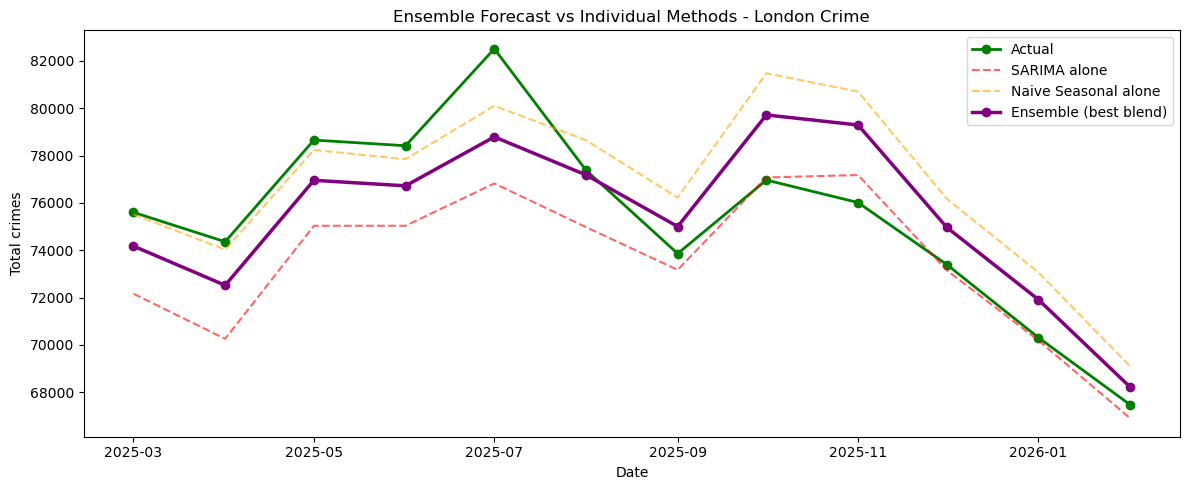

                     Method     MAE
0              SARIMA alone  2127.0
1      Naive Seasonal alone  1983.5
2  Ensemble (0.4/0.6 blend)  1806.1


In [4]:
import matplotlib.pyplot as plt

best_weight = 0.4
final_ensemble = (best_weight * sarima_forecast.values) + ((1 - best_weight) * naive_seasonal_forecast.values)

mae_final = np.mean(np.abs(test.values - final_ensemble))
print("Final ensemble (0.4 SARIMA / 0.6 Naive Seasonal) MAE:", round(mae_final, 1))

plt.figure(figsize=(12, 5))
plt.plot(test.index, test.values, label="Actual", color="green", marker="o", linewidth=2)
plt.plot(test.index, sarima_forecast.values, label="SARIMA alone", color="red", linestyle="--", alpha=0.6)
plt.plot(test.index, naive_seasonal_forecast.values, label="Naive Seasonal alone", color="orange", linestyle="--", alpha=0.6)
plt.plot(test.index, final_ensemble, label="Ensemble (best blend)", color="purple", marker="o", linewidth=2.5)

plt.title("Ensemble Forecast vs Individual Methods - London Crime")
plt.xlabel("Date")
plt.ylabel("Total crimes")
plt.legend()
plt.tight_layout()
plt.savefig("figures/19_ensemble_comparison.png", dpi=150)
plt.show()

final_comparison = pd.DataFrame({
    "Method": ["SARIMA alone", "Naive Seasonal alone", "Ensemble (0.4/0.6 blend)"],
    "MAE": [2127.0, 1983.5, round(mae_final, 1)]
})
final_comparison.to_csv("data/ensemble_results.csv", index=False)
print(final_comparison)

In [5]:
train_feb = london_monthly[:"2026-02-01"]

model_feb = SARIMAX(train_feb, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12))
fitted_feb = model_feb.fit(disp=False)
sarima_forecast_feb = fitted_feb.forecast(steps=4)

naive_seasonal_feb = london_monthly.shift(12)["2026-03-01":"2026-06-01"]

actual_mar_jun = pd.Series([75137, 73990, 78652, 79894], 
                             index=pd.date_range("2026-03-01", periods=4, freq="MS"))

ensemble_feb = (0.4 * sarima_forecast_feb.values) + (0.6 * naive_seasonal_feb.values)

mae_sarima_feb = np.mean(np.abs(actual_mar_jun.values - sarima_forecast_feb.values))
mae_naive_feb = np.mean(np.abs(actual_mar_jun.values - naive_seasonal_feb.values))
mae_ensemble_feb = np.mean(np.abs(actual_mar_jun.values - ensemble_feb))

print("SARIMA alone MAE:", round(mae_sarima_feb, 1))
print("Naive Seasonal alone MAE:", round(mae_naive_feb, 1))
print("Ensemble MAE:", round(mae_ensemble_feb, 1))

comparison = pd.DataFrame({
    "Actual": actual_mar_jun.values,
    "SARIMA": sarima_forecast_feb.values.round(0),
    "Naive Seasonal": naive_seasonal_feb.values,
    "Ensemble": ensemble_feb.round(0)
}, index=actual_mar_jun.index)
print(comparison)

ValueError: operands could not be broadcast together with shapes (4,) (0,) 

In [6]:
naive_seasonal_feb = pd.Series([
    london_monthly["2025-03-01"],
    london_monthly["2025-04-01"],
    london_monthly["2025-05-01"],
    london_monthly["2025-06-01"]
], index=pd.date_range("2026-03-01", periods=4, freq="MS"))

print(naive_seasonal_feb)

2026-03-01    75599
2026-04-01    74357
2026-05-01    78653
2026-06-01    78414
Freq: MS, dtype: int64


In [7]:
model_feb = SARIMAX(train_feb, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12))
fitted_feb = model_feb.fit(disp=False)
sarima_forecast_feb = fitted_feb.forecast(steps=4)

actual_mar_jun = pd.Series([75137, 73990, 78652, 79894], 
                             index=pd.date_range("2026-03-01", periods=4, freq="MS"))

ensemble_feb = (0.4 * sarima_forecast_feb.values) + (0.6 * naive_seasonal_feb.values)

mae_sarima_feb = np.mean(np.abs(actual_mar_jun.values - sarima_forecast_feb.values))
mae_naive_feb = np.mean(np.abs(actual_mar_jun.values - naive_seasonal_feb.values))
mae_ensemble_feb = np.mean(np.abs(actual_mar_jun.values - ensemble_feb))

print("SARIMA alone MAE:", round(mae_sarima_feb, 1))
print("Naive Seasonal alone MAE:", round(mae_naive_feb, 1))
print("Ensemble MAE:", round(mae_ensemble_feb, 1))

comparison = pd.DataFrame({
    "Actual": actual_mar_jun.values,
    "SARIMA": sarima_forecast_feb.values.round(0),
    "Naive Seasonal": naive_seasonal_feb.values,
    "Ensemble": ensemble_feb.round(0)
}, index=actual_mar_jun.index)
print(comparison)

SARIMA alone MAE: 2707.3
Naive Seasonal alone MAE: 577.5
Ensemble MAE: 1180.4
            Actual   SARIMA  Naive Seasonal  Ensemble
2026-03-01   75137  73103.0           75599   74600.0
2026-04-01   73990  71817.0           74357   73341.0
2026-05-01   78652  76096.0           78653   77630.0
2026-06-01   79894  75829.0           78414   77380.0
